In [1]:
import urllib.request
import zipfile,os

url = 'http://dihana.cps.unizar.es/~cadrete/curso_asr_unizar/wav.zip'
if not os.path.exists('wav.zip'):
    urllib.request.urlretrieve(url, 'wav.zip')
    with zipfile.ZipFile('wav.zip', 'r') as zip_ref:
        zip_ref.extractall()

# check for more at: https://github.com/openai/whisper/blob/main/whisper/__init__.py#L17

url = 'https://openaipublic.azureedge.net/main/whisper/models/9ecf779972d90ba49c06d968637d720dd632c55bbf19d441fb42bf17a411e794/small.pt'
if not os.path.exists('small.pt'):
    urllib.request.urlretrieve(url, 'small.pt')

url = 'https://openaipublic.azureedge.net/main/whisper/models/345ae4da62f9b3d59415adc60127b97c714f32e89e936602e85993674d08dcb1/medium.pt'
if not os.path.exists('medium.pt'):
    urllib.request.urlretrieve(url, 'medium.pt')

url = 'https://raw.githubusercontent.com/openai/whisper/refs/heads/main/whisper/assets/multilingual.tiktoken'
if not os.path.exists('multilingual.tiktoken'):
    urllib.request.urlretrieve(url, 'multilingual.tiktoken')

In [21]:
import numpy as np
import base64, itertools, tiktoken
import torch, torchaudio, librosa 

In [22]:

LANGUAGES = ['en', 'zh', 'de', 'es', 'ru', 'ko', 'fr', 'ja', 'pt', 'tr', 'pl', 'ca', 'nl', 'ar', 'sv', 'it', 'id', 'hi', 'fi', 'vi', 'he', 'uk', 'el', 'ms', 'cs', 'ro', 'da', 'hu', 'ta', 'no', 'th', 'ur', 'hr', 'bg', 'lt', 'la', 'mi', 'ml', 'cy', 'sk', 'te', 'fa', 'lv', 'bn', 'sr', 'az', 'sl', 'kn', 'et', 'mk', 'br', 'eu', 'is', 'hy', 'ne', 'mn', 'bs', 'kk', 'sq', 'sw', 'gl', 'mr', 'pa', 'si', 'km', 'sn', 'yo', 'so', 'af', 'oc', 'ka', 'be', 'tg', 'sd', 'gu', 'am', 'yi', 'lo', 'uz', 'fo', 'ht', 'ps', 'tk', 'nn', 'mt', 'sa', 'lb', 'my', 'bo', 'tl', 'mg', 'as', 'tt', 'haw', 'ln', 'ha', 'ba', 'jw', 'su']

with open('multilingual.tiktoken') as f:
    ranks = {base64.b64decode(token): int(rank) for token, rank in (line.split() for line in f if line)}
n_vocab = len(ranks)
specials = [
"<|endoftext|>",
"<|startoftranscript|>",
*[f"<|{lang}|>" for lang in LANGUAGES],
"<|translate|>",
"<|transcribe|>",
"<|startoflm|>",
"<|startofprev|>",
"<|nospeech|>",
"<|notimestamps|>",
*[f"<|{i * 0.02:.2f}|>" for i in range(1501)],
]
special_tokens = dict(zip(specials, itertools.count(n_vocab)))
n_vocab += len(specials)
print('vocab_size: ', n_vocab)
tokenizer = tiktoken.Encoding(
    name="multilingual",
    explicit_n_vocab=n_vocab,
    pat_str=r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+""",
    mergeable_ranks=ranks,
    special_tokens=special_tokens)


print( tokenizer.encode(" Francia, Suiza y Hungría ya hicieron causa común.") )

vocab_size:  51865
[17288, 2755, 11, 2746, 13427, 288, 11648, 861, 2686, 2478, 23697, 14440, 23667, 45448, 13]


In [23]:

class MultiHeadSelfAttention(torch.nn.Module):
    def __init__(self, n_state, n_head):
        super().__init__()
        self.n_head = n_head
        self.d_head = n_state // n_head
        self.scale = self.d_head ** 0.50
        self.query = torch.nn.Linear(n_state, n_state)
        self.key = torch.nn.Linear(n_state, n_state, bias=False)
        self.value = torch.nn.Linear(n_state, n_state)
        self.out = torch.nn.Linear(n_state, n_state)    

    def forward(self, x):
        b, n = x.shape[:2]
        q = self.query(x).reshape(b, n, self.n_head, self.d_head)
        k = self.key(x).reshape(b, n, self.n_head, self.d_head)
        v = self.value(x).reshape(b, n, self.n_head, self.d_head)
        scores = torch.einsum('bihd,bjhd->bhij', q, k) / self.scale
        att = scores.softmax(dim=-1)
        wv = torch.einsum('bhij,bjhd->bihd', att, v).reshape(b, n, self.n_head*self.d_head)
        return self.out(wv)

class MultiHeadCausalAttention(MultiHeadSelfAttention):
    def forward(self, x, mask=None):
        b, n = x.shape[:2]
        q = self.query(x).reshape(b, n, self.n_head, self.d_head)
        k = self.key(x).reshape(b, n, self.n_head, self.d_head)
        v = self.value(x).reshape(b, n, self.n_head, self.d_head)
        scores = torch.einsum('bihd,bjhd->bhij', q, k) / self.scale    
        scores = scores.masked_fill(mask[:,:,:n,:n], -torch.inf)
        att = scores.softmax(dim=-1)
        wv = torch.einsum('bhij,bjhd->bihd', att, v).reshape(b,n, self.n_head*self.d_head)
        return self.out(wv)
  
class MultiHeadCrossAttention(MultiHeadSelfAttention):
    def forward(self, x, xa):
        b, n = x.shape[:2]
        q = self.query(x).reshape(b, n, self.n_head, self.d_head)
        k = self.key(xa).reshape(b, -1, self.n_head, self.d_head)
        v = self.value(xa).reshape(b, -1, self.n_head, self.d_head)
        scores = torch.einsum('bihd,bjhd->bhij', q, k) / self.scale
        att = scores.softmax(dim=-1)
        wv = torch.einsum('bhij,bjhd->bihd', att, v).reshape(b, n, self.n_head*self.d_head)
        return self.out(wv), scores
      
class ResidualAttentionBlockEncoder(torch.nn.Module):
    def __init__(self, n_state, n_head):
        super().__init__()
        self.attn = MultiHeadSelfAttention(n_state, n_head)
        self.attn_ln = torch.nn.LayerNorm(n_state)
        self.mlp = torch.nn.Sequential(torch.nn.Linear(n_state, n_state*4), 
                                      torch.nn.GELU(), 
                                      torch.nn.Linear(n_state*4, n_state))    
        self.mlp_ln = torch.nn.LayerNorm(n_state)

    def forward(self, x):
        x = x + self.attn(self.attn_ln(x))    
        x = x + self.mlp(self.mlp_ln(x))
        return x 

class ResidualAttentionBlockDecoder(torch.nn.Module):
    def __init__(self, n_state, n_head):
        super().__init__()
        self.attn = MultiHeadCausalAttention(n_state, n_head)
        self.attn_ln = torch.nn.LayerNorm(n_state)
        self.cross_attn = MultiHeadCrossAttention(n_state, n_head)
        self.cross_attn_ln = torch.nn.LayerNorm(n_state) 
        self.mlp = torch.nn.Sequential(torch.nn.Linear(n_state, n_state*4), 
                                      torch.nn.GELU(), 
                                      torch.nn.Linear(n_state*4, n_state))
        self.mlp_ln = torch.nn.LayerNorm(n_state)

    def forward(self, x, xa, mask=None):
        x = x + self.attn(self.attn_ln(x), mask=mask)
        x = x + self.cross_attn(self.cross_attn_ln(x), xa)[0]
        x = x + self.mlp(self.mlp_ln(x))
        return x 
      
class AudioFeatures(torch.nn.Module):
    def __init__(self, n_mels):
        super().__init__()
        self.register_buffer('window', torch.hann_window(400))
        self.register_buffer('filters', torch.from_numpy(librosa.filters.mel(sr=16000, n_fft=400, n_mels=n_mels)))

    def forward(self, audio):
        stft = torch.stft(audio, 400, 160, window=self.window, return_complex=True)
        magnitudes = stft[..., :-1].abs() ** 2
        mel_spec = self.filters @ magnitudes
        log_spec = torch.clamp(mel_spec, min=1e-10).log10()
        log_spec = torch.maximum(log_spec, log_spec.max() - 8.0)
        return (log_spec + 4.0) / 4.0

class AudioEncoder(torch.nn.Module):
    def __init__(self, n_mels, n_audio_ctx, n_audio_state, n_audio_head, n_audio_layer, **_):
        super().__init__()
        self.conv1 = torch.nn.Conv1d(n_mels, n_audio_state, kernel_size=3, padding=1)
        self.conv2 = torch.nn.Conv1d(n_audio_state, n_audio_state, kernel_size=3, stride=2, padding=1)
        self.blocks = torch.nn.Sequential(
            *[ResidualAttentionBlockEncoder(n_audio_state, n_audio_head) for _ in range(n_audio_layer)])
        self.ln_post = torch.nn.LayerNorm(n_audio_state)
        self.positional_embedding = torch.nn.Parameter(torch.randn(n_audio_ctx, n_audio_state))
        self.fe = AudioFeatures(n_mels)

    def forward(self, x):
        x = self.fe(x)
        x = self.conv1(x)
        x = torch.nn.functional.gelu(x)
        x = self.conv2(x)
        x = torch.nn.functional.gelu(x)
        x = x.transpose(1, 2)
        x = x + self.positional_embedding[:x.shape[1]]
        x = self.blocks(x)
        x = self.ln_post(x)
        return x  
    

class TextDecoder(torch.nn.Module):
    def __init__(self, n_vocab, n_text_ctx, n_text_state, n_text_head, n_text_layer, **_):
        super().__init__()
        self.max_tokens_to_sample = n_text_ctx // 2
        
        self.token_embedding = torch.nn.Embedding(n_vocab, n_text_state)
        self.positional_embedding =  torch.nn.Parameter(torch.randn(n_text_ctx, n_text_state))
        
        self.blocks = torch.nn.ModuleList(
              [ResidualAttentionBlockDecoder(n_text_state, n_text_head) 
                  for _ in range(n_text_layer)])
        self.ln = torch.nn.LayerNorm(n_text_state)
        self.register_buffer('mask', torch.tril(torch.ones(n_text_ctx, n_text_ctx)).view(1, 1, n_text_ctx, n_text_ctx) == 0)
        
    def forward(self, x, encoded_audio):
        seqlen = x.shape[-1]
        x = self.token_embedding(x) + self.positional_embedding[:seqlen]
        for block in self.blocks:
            x = block(x, xa=encoded_audio, mask=self.mask)
        return self.ln(x) @ self.token_embedding.weight.T

class Whisper(torch.nn.Module):
    def __init__(self, dims, 
                       tokens_ini=[50258, 50262, 50359, 50363],  #startoftranscript, startoftranscript+1+lang, transcribe, notimestamps 
                       startofprev=50361, 
                       endoftext=50257):
        super().__init__()
        self.encoder = AudioEncoder(**dims)
        self.decoder = TextDecoder(**dims)
        self.tokens_ini = tokens_ini
        self.startofprev = startofprev
        self.endoftext = endoftext

    def generate_greedy(self, audio, prompt=[], device='cuda'):
        with torch.no_grad():
            encoded_audio = self.encoder(audio)    
            tokens = self.tokens_ini.copy()
            if len(prompt) > 0:  # add the prompt to tokens
                tokens = [self.startofprev] + prompt + tokens 
            input_tokens = torch.LongTensor([tokens]).to(device)
            for i in range(self.decoder.max_tokens_to_sample):      
                logits = self.decoder(input_tokens, encoded_audio)               
                next_token = logits[:, -1].argmax(axis=-1).item()
                tokens.append(next_token)     
                input_tokens = torch.LongTensor([tokens]).to(device)
                if tokens[-1] == self.endoftext: 
                    break             
            ini = tokens.index(self.tokens_ini[-1]) 
            return tokens, ini
      

# asr

In [24]:
device = 'cuda'
# state = torch.load('small.pt')
state = torch.load('medium.pt')
model = Whisper(state['dims'])
model.load_state_dict(state['model_state_dict'], strict=False)
model = model.to(device)


OutOfMemoryError: CUDA out of memory. Tried to allocate 16.00 MiB. GPU 0 has a total capacity of 31.36 GiB of which 4.88 MiB is free. Process 1517538 has 12.02 GiB memory in use. Process 1518365 has 1.09 GiB memory in use. Including non-PyTorch memory, this process has 18.14 GiB memory in use. Of the allocated memory 17.46 GiB is allocated by PyTorch, and 80.21 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
wav = 'wav/audio3.wav'
# wav = 'wav/audio4.wav'
audio = torchaudio.load(wav)[0].to(device)
t_audio = audio.shape[-1] 
# to pad and trim audio to 30 seconds
audio = audio[:, :16000 * 30]
if audio.shape[-1] < 16000 * 30:
    audio = torch.nn.functional.pad(audio, (0, 16000 * 30 - audio.shape[-1]))
print(audio.shape)

torch.Size([1, 480000])


Plot mel spectrogram and play

torch.Size([80, 3000])


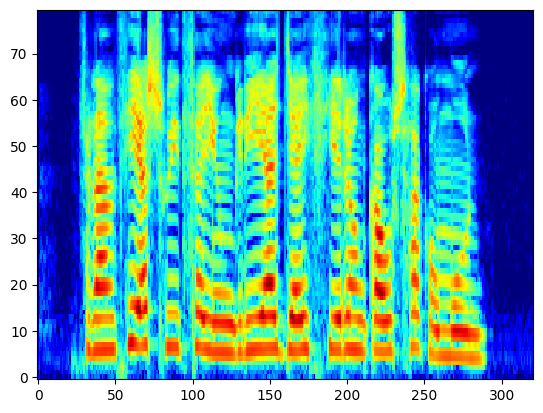

In [ ]:
mel = model.encoder.fe(audio)[0]
print(mel.shape)
import matplotlib.pyplot as plt
plt.imshow( mel[:,:t_audio//160].detach().cpu().numpy(), interpolation='none', origin='lower', cmap='jet', aspect='auto')
import IPython
IPython.display.Audio(wav)

In [ ]:
prompt = ''
prompt = tokenizer.encode(prompt.strip())
print(prompt)
tokens, ini = model.generate_greedy(audio, prompt=prompt)
print(tokens)
print(tokenizer.decode(tokens).strip())
print(tokenizer.decode(tokens[ini+1:-1]).strip())

[]


[50258, 50262, 50359, 50363, 17288, 2755, 11, 2746, 13427, 288, 11648, 861, 2686, 2478, 23697, 14440, 23667, 45448, 13, 50257]
<|startoftranscript|><|es|><|transcribe|><|notimestamps|> Francia, Suiza y Hungría ya hicieron causa común.<|endoftext|>
Francia, Suiza y Hungría ya hicieron causa común.


# plot attention

In [ ]:
QKs = [None] * len(model.decoder.blocks)
for i, block in enumerate(model.decoder.blocks):
    block.cross_attn.register_forward_hook(
        lambda _, ins, outs, index=i: QKs.__setitem__(index, outs[-1])
    )

model.decoder(torch.LongTensor([tokens]).to(device),model.encoder(audio))


tensor([[[ 4.8438,  4.6732, 11.6277,  ...,  9.5459, 10.5942, 16.5231],
         [ 2.6476,  2.0094,  2.7476,  ...,  1.0860,  0.2650,  2.2643],
         [-2.9154, -5.0133, -8.7242,  ..., -8.9106, -8.8217, -8.8210],
         ...,
         [29.5424, 30.0942, 24.3606,  ..., 21.6621, 21.7888, 19.8235],
         [-2.3844,  0.2820,  0.6672,  ..., -0.9742, -0.3993, -2.4952],
         [ 2.6647,  2.5854,  2.6571,  ..., -2.1574, -1.9580, -3.3895]]],
       device='cuda:0', grad_fn=<UnsafeViewBackward0>)

In [ ]:
weights = torch.cat(QKs).detach() # layers * heads * tokens * frames    

from scipy.ndimage import median_filter
medfilt_width = 7
qk_scale = 1.0   
weights = weights[:, :, :, :t_audio//320 ].cpu()
weights = median_filter(weights, (1, 1, 1, medfilt_width))
weights = torch.tensor(weights * qk_scale).softmax(dim=-1)

w = weights / weights.norm(dim=-2, keepdim=True)
matrix = w[-6:].mean(axis=(0, 1))

import matplotlib.pyplot as plt
plt.imshow(matrix[:,:],  aspect="auto", interpolation='none')
t_ = [tokenizer.decode([t,]) for t in tokens]
plt.gca().set_yticks(np.arange(len(t_)), t_, fontsize=7)
print(weights.shape)

OutOfMemoryError: CUDA out of memory. Tried to allocate 44.00 MiB. GPU 0 has a total capacity of 31.36 GiB of which 36.88 MiB is free. Process 1517538 has 12.02 GiB memory in use. Process 1518365 has 1.09 GiB memory in use. Including non-PyTorch memory, this process has 18.11 GiB memory in use. Of the allocated memory 17.43 GiB is allocated by PyTorch, and 77.11 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

torch.Size([24, 16, 20, 160])


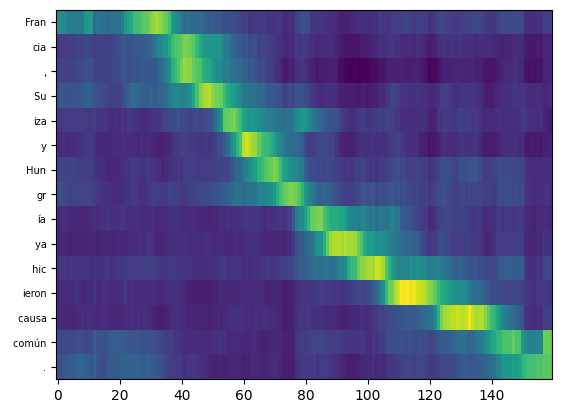

In [ ]:
plt.imshow(matrix[ini+1:-1,:],  aspect="auto", interpolation='none')
t_ = [tokenizer.decode([t,]) for t in tokens[ini+1:-1]]
plt.gca().set_yticks(np.arange(len(t_)), t_, fontsize=7)
print(weights.shape)